In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r'D:\Python\project\data-science\data\raw\bsb_bank_statement.csv')

In [6]:
print(df.shape)
print(df.columns.tolist())
print(df.head())

(4571, 9)
['Дата операции', 'Дата транзакции', '4 последние цифры номера карточки', 'Описание операции', 'Место проведения транзакции', 'Валюта транзакции', 'Сумма транзакции', 'Сумма в валюте карт-счета', 'Остаток карт-счета']
  Дата операции Дата транзакции  4 последние цифры номера карточки  \
0    2023-05-12      2023-05-12                             4995.0   
1    2023-05-29      2023-05-28                             4995.0   
2    2023-05-29      2023-05-28                             4995.0   
3    2023-05-29      2023-05-28                             4995.0   
4    2023-05-29      2023-05-28                             8176.0   

                                   Описание операции  \
0  Online открытие текущего счета с последующим в...   
1  Оплата товаров и услуг в устройствах других ба...   
2  Оплата товаров и услуг в устройствах других ба...   
3         Оплата товаров и услуг в устройствах Банка   
4                              Пополнение счета Ерип   

   Место прове

In [7]:
# Переименуем колонки для удобства (короткие английские названия)
df.columns = [
    'operation_date', 'transaction_date', 'card_last4',
    'description', 'place', 'currency',
    'amount_original', 'amount', 'balance'
]

# Преобразуем даты
df['operation_date'] = pd.to_datetime(df['operation_date'])
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Смотрим пропуски
print(df.isnull().sum())

# Основные типы операций
print(df['description'].value_counts().head(10))

operation_date       0
transaction_date     0
card_last4          84
description          0
place               87
currency             0
amount_original      0
amount               0
balance              0
dtype: int64
description
Оплата товаров и услуг в устройствах других банков                 4049
Пополнение счета Ерип                                               178
Оплата товаров и услуг в устройствах Банка                          105
Капитализация (%% тек.периода ко вкладу)                             37
Начисление Money- back (Программа money-back "Стандарт")             37
Оплата товаров и услуг                                               26
Оплата товаров и услуг в устройствах                                 25
Оплата товаров и услуг в устройствах других                          25
Списание P2P в устройствах других банков                             20
Плата за перевод с карт-счета на карт-счет (в устр. др. банков)      16
Name: count, dtype: int64


In [8]:
# Создаём признак: это расход или пополнение
df['is_expense'] = df['description'].str.contains('Оплата|Списание|Плата|Снятие', case=False, na=False)
df['is_income'] = df['description'].str.contains('Пополнение|Начисление|Возвращенная|Капитализация', case=False, na=False)

# Топ мест по сумме расходов
expenses = df[df['is_expense']]
print("Топ-15 мест по сумме расходов:")
print(expenses.groupby('place')['amount'].sum().sort_values(ascending=False).head(15))

Топ-15 мест по сумме расходов:
place
INTERNET-BANKING BSB         19635.95
UNIVERSAM                     4429.33
PERSON TO PERSON MP BSB       4228.00
SHOP SOSEDI                   3400.68
SHOP "SANTA-270" BAPB         3211.23
SHOP "SOSEDI"                 3183.30
SHOP "EUROOPT PRIME"          2733.99
WWW.WILDBERRIES.BY            1840.09
SHOP "EVROOPT"                1279.67
I.-SHOP "WILDBERRIES.BY"      1088.89
SHOP "GALAMART" BAPB          1066.88
MINI-KAFE PIZZA LISITSTSA     1065.45
BUFET                         1042.63
MAGAZIN EUROOPT PRIME          959.63
SHOP "MILA"                    921.94
Name: amount, dtype: float64


In [9]:
# Приводим названия мест к единому виду
df['place_clean'] = df['place'].str.upper().str.replace('"', '', regex=False).str.strip()

# Теперь смотрим топ мест после очистки
expenses = df[df['is_expense']]
print("Топ-15 мест после очистки:")
print(expenses.groupby('place_clean')['amount'].sum().sort_values(ascending=False).head(15))

Топ-15 мест после очистки:
place_clean
INTERNET-BANKING BSB         19635.95
SHOP SOSEDI                   6583.98
UNIVERSAM                     4429.33
PERSON TO PERSON MP BSB       4228.00
SHOP SANTA-270 BAPB           3211.23
SHOP EUROOPT PRIME            2733.99
WWW.WILDBERRIES.BY            1840.09
SHOP MILA                     1752.54
SHOP EVROOPT                  1282.50
I.-SHOP WILDBERRIES.BY        1088.89
SHOP GALAMART BAPB            1066.88
MINI-KAFE PIZZA LISITSTSA     1065.45
BUFET                         1042.63
MAGAZIN EUROOPT PRIME          959.63
RBO BURGER KING                704.38
Name: amount, dtype: float64


Расходы по месяцам:
month
2023-05     160.47
2023-06    1123.33
2023-07    1004.84
2023-08    1241.81
2023-09    1808.11
2023-10    1472.64
2023-11    1145.19
2023-12    1594.18
2024-01    1464.20
2024-02    1544.71
2024-03    1440.61
2024-04    2700.43
2024-05    1951.90
2024-06    2404.54
2024-07    2549.81
2024-08    2513.00
2024-09    2370.35
2024-10    2726.35
2024-11    2954.09
2024-12    2298.69
2025-01    2734.11
2025-02    2477.70
2025-03    3044.52
2025-04    1998.13
2025-05    2579.02
2025-06    2227.30
2025-07    2623.33
2025-08    2645.36
2025-09    2556.12
2025-10    2542.54
2025-11    2505.65
2025-12    3394.92
2026-01    2481.16
2026-02    2770.21
2026-03    3188.43
2026-04    2870.26
2026-05    2477.19
2026-06    1696.12
Freq: M, Name: amount, dtype: float64


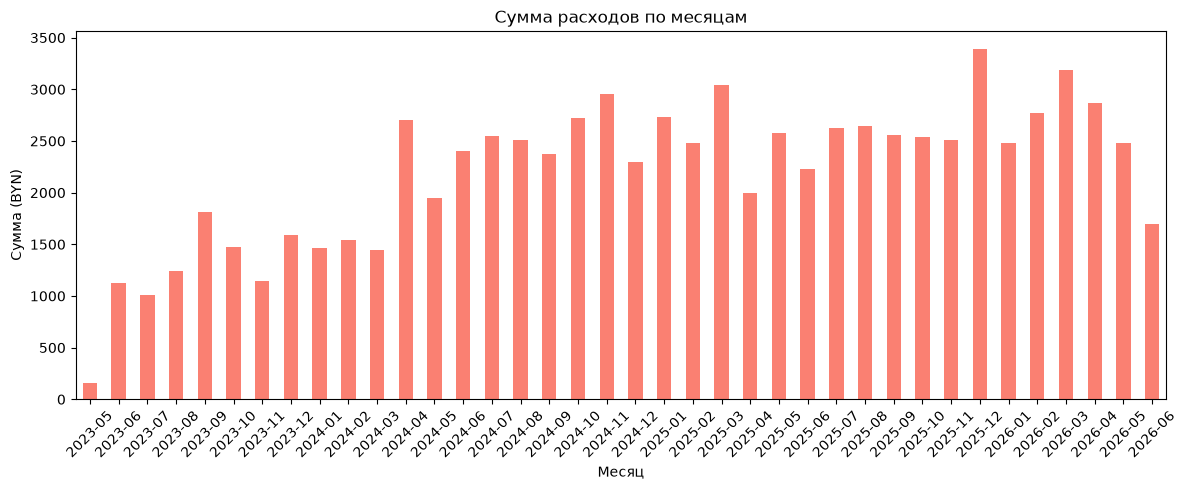

In [12]:
# Сначала добавляем месяц ко всему df
df['month'] = df['operation_date'].dt.to_period('M')

# Теперь заново создаём expenses (уже с колонкой month)
expenses = df[df['is_expense']]

# Расходы по месяцам
monthly_expenses = expenses.groupby('month')['amount'].sum()

print("Расходы по месяцам:")
print(monthly_expenses)

# График
plt.figure(figsize=(12, 5))
monthly_expenses.plot(kind='bar', color='salmon')
plt.title('Сумма расходов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Сумма (BYN)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Словарь соответствий (будем постепенно дополнять)
category_map = {
    'UNIVERSAM': 'Продукты',
    'SHOP SOSEDI': 'Продукты',
    'SHOP "SOSEDI"': 'Продукты',
    'SHOP "SANTA-270" BAPB': 'Продукты',
    'SHOP "EVROOPT"': 'Продукты',
    'SHOP "EUROOPT PRIME"': 'Продукты',
    'MAGAZIN EUROOPT PRIME': 'Продукты',
    'SHOP "MILA"': 'Продукты',
    'SHOP MILA': 'Продукты',
    
    'BUFET': 'Кафе и рестораны',
    'BUFET STOLOVOY N 6': 'Кафе и рестораны',
    'MINI-KAFE PIZZA LISITSTSA': 'Кафе и рестораны',
    'RBO "BURGER KING"': 'Кафе и рестораны',
    
    'TRANSPORT PAYBYCARD.BY': 'Транспорт',
    'YANDEX GO': 'Транспорт',
    
    'WWW.WILDBERRIES.BY': 'Онлайн-магазины',
    'I.-SHOP "WILDBERRIES.BY"': 'Онлайн-магазины',
    
    'INTERNET-BANKING BSB': 'Банковские операции',
    'ON-LINE POPOLNENIE ERIP BSB': 'Пополнения',
}

# Создаём колонку Category
df['category'] = df['place_clean'].map(category_map).fillna('Прочее')

print(df['category'].value_counts())

category
Прочее                 2691
Продукты               1071
Кафе и рестораны        348
Транспорт               203
Пополнения              181
Онлайн-магазины          47
Банковские операции      30
Name: count, dtype: int64


In [14]:
def get_category(place):
    if pd.isna(place):
        return 'Прочее'
    
    place = str(place).upper()
    
    # Продукты
    if any(word in place for word in ['SOSEDI', 'SANTA', 'EVROOPT', 'EUROOPT', 'UNIVERSAM', 'GIPPO', 'GREEN', 'MILA', 'GALAMART', 'PROSTORE', 'ALMI']):
        return 'Продукты'
    
    # Кафе и рестораны
    if any(word in place for word in ['KAFE', 'CAFÉ', 'RESTORAN', 'БУФЕТ', 'BUFET', 'STOLOV', 'PIZZA', 'BURGER', 'KFC', 'SUSHI', 'SHAVERMA', 'DONER', 'KEBAB']):
        return 'Кафе и рестораны'
    
    # Транспорт
    if any(word in place for word in ['TRANSPORT', 'YANDEX', 'TAXI', 'АЗС', 'AZS', 'МАЗС']):
        return 'Транспорт'
    
    # Онлайн-магазины
    if any(word in place for word in ['WILDBERRIES', 'OZON', 'JOOM', 'ALIEXPRESS']):
        return 'Онлайн-магазины'
    
    # Аптеки
    if any(word in place for word in ['APTEKA', 'АПТЕКА', 'PHARM']):
        return 'Аптеки'
    
    # Связь
    if any(word in place for word in ['COSMOS', 'TELECOM', 'МТС', 'A1', 'LIFE']):
        return 'Связь'
    
    # Банковские операции
    if any(word in place for word in ['INTERNET-BANKING', 'ERIP', 'PEREVOD', 'P2P', 'COMPAY']):
        return 'Банковские операции'
    
    return 'Прочее'

# Применяем функцию
df['category'] = df['place'].apply(get_category)

print(df['category'].value_counts())

category
Продукты               1672
Прочее                 1320
Кафе и рестораны        912
Банковские операции     257
Транспорт               234
Онлайн-магазины          91
Аптеки                   65
Связь                    20
Name: count, dtype: int64


In [15]:
# Смотрим, что осталось в категории «Прочее»
prochee = df[df['category'] == 'Прочее']

print("Количество записей в Прочее:", len(prochee))
print("\nТоп-40 мест, которые всё ещё в Прочее:")
print(prochee['place'].value_counts().head(40))

Количество записей в Прочее: 1320

Топ-40 мест, которые всё ещё в Прочее:
place
ZAO Superprod                 51
I.-SHOP"WWW.PASS.RW.BY"       29
SHOP IZYUM                    28
ZAKUS. "B.PEREMENA"BAPB       24
TO "OOO VKUSFRI I K"          20
SHOP "KHIT STANDART"          20
TORG.MESTO N3                 19
SHOP N9869                    16
SHOP "NASHA LAVKA N2" BAP     16
TM N3                         14
HELLO                         14
FIRM.SHOP "KARAVAY" BAPB      13
SHOP "KOPEECHKA"              13
SHOP "KHIT EKSPRESS"          13
TP "KOLOBOK" BAPB             13
LOTUS BUBBLE TEA              13
Vesyolyj ponchik              12
SHOP "MAYAK"                  12
KOP                           12
SHOP N9863                    11
SHOP TRI TSENY                11
KOFEYNYA BAPB                 11
PAV. N66 BAPB                 10
TORGOVY LOTOK "KOFE SAUND"    10
SHOP N9863 FIX PRICE          10
TORGOVY OBEKT BAPB             9
SHOP "TRI TSENY"               9
Mag.Karandash                

In [16]:
# Приводим place к верхнему регистру и убираем все кавычки
df['place'] = (
    df['place']
    .astype(str)                    # на всякий случай делаем строкой
    .str.upper()                    # всё в верхний регистр
    .str.replace('"', '', regex=False)  # убираем обычные кавычки
    .str.replace('«', '', regex=False)  # убираем ёлочки (если есть)
    .str.replace('»', '', regex=False)
    .str.strip()                    # убираем лишние пробелы по краям
)

# Проверяем результат
print(df['place'].value_counts().head(20))

place
SHOP SOSEDI                    548
UNIVERSAM                      423
BUFET                          196
ON-LINE POPOLNENIE ERIP BSB    181
TRANSPORT PAYBYCARD.BY         162
SHOP SANTA-270 BAPB            158
BUFET STOLOVOY N 6             112
SHOP EVROOPT                    88
RBO BURGER KING                 86
SHOP EUROOPT PRIME              80
SHOP MILA                       77
ZAO SUPERPROD                   51
STOLOVAYA N 6                   47
WWW.WILDBERRIES.BY              47
SHOP GALAMART BAPB              44
YANDEX GO                       41
MINI-KAFE PIZZA LISITSTSA       40
I.-SHOP WILDBERRIES.BY          37
COMPAY BIB EPAYMENTS OPLA       35
INTERNET-BANKING BSB            30
Name: count, dtype: int64


In [17]:
prochee = df[df['category'] == 'Прочее']

print("Количество записей в Прочее:", len(prochee))
print("\nТоп-40 мест, которые всё ещё в Прочее:")
print(prochee['place'].value_counts().head(40))

Количество записей в Прочее: 1320

Топ-40 мест, которые всё ещё в Прочее:
place
ZAO SUPERPROD               51
I.-SHOPWWW.PASS.RW.BY       29
SHOP IZYUM                  28
ZAKUS. B.PEREMENABAPB       24
TO OOO VKUSFRI I K          20
SHOP KHIT STANDART          20
SHOP TRI TSENY              20
TORG.MESTO N3               19
SHOP KOPEECHKA              17
SHOP N9869                  16
SHOP NASHA LAVKA N2 BAP     16
SHOP MAYAK                  15
TM N3                       14
HELLO                       14
FIRM.SHOP KARAVAY BAPB      13
SHOP KHIT EKSPRESS          13
TP KOLOBOK BAPB             13
LOTUS BUBBLE TEA            13
VESYOLYJ PONCHIK            12
KOP                         12
SHOP N9863                  11
KOFEYNYA BAPB               11
PAV. N66 BAPB               10
TORGOVY LOTOK KOFE SAUND    10
SHOP N9863 FIX PRICE        10
TORGOVY OBEKT BAPB           9
MAG.KARANDASH                9
CRISPY                       9
SHOP N11 VITEB.PRODUKTY      9
MAGAZIN N4           

In [ ]:
def get_category(place):
    if pd.isna(place):
        return 'Прочее'
    
    place = str(place).upper()
    
    # 1. Продукты
    if any(word in place for word in ['SOSEDI', 'SANTA', 'EVROOPT', 'EUROOPT', 'UNIVERSAM', 'GIPPO', 'GREEN', 'MILA', 'GALAMART', 'PROSTORE', 'ALMI', 'IZYUM', 'KOPEECHKA', 'KARAVAY', 'NASHA LAVKA', 'MAYAK', 'TRI TSENY', 'FIX PRICE', 'SUPERPROD', 'PRODUKTY']):
        return 'Продукты'
    
    # 2. Кафе и рестораны
    if any(word in place for word in ['KAFE', 'CAFÉ', 'RESTORAN', 'БУФЕТ', 'BUFET', 'STOLOV', 'PIZZA', 'BURGER', 'KFC', 'SUSHI', 'SHAVERMA', 'DONER', 'KEBAB', 'PEREMENA', 'VKUSFRI', 'BUBBLE TEA', 'COFFEE', 'KOFE', 'CRISPY', 'PONCHIK']):
        return 'Кафе и рестораны'
    
    # 3. Транспорт
    if any(word in place for word in ['TRANSPORT', 'YANDEX', 'TAXI', 'АЗС', 'AZS', 'МАЗС', 'PASS.RW', 'HELLO']):
        return 'Транспорт'
    
    # 4. Онлайн-магазины
    if any(word in place for word in ['WILDBERRIES', 'OZON', 'JOOM', 'ALIEXPRESS']):
        return 'Онлайн-магазины'
    
    # 5. Аптеки
    if any(word in place for word in ['APTEKA', 'АПТЕКА', 'PHARM',]):
        return 'Аптеки'
    
    # 6. Связь
    if any(word in place for word in ['COSMOS', 'TELECOM']):
        return 'Связь'
    
    # 7. Развлечения
    if any(word in place for word in ['KINO', 'SKYLINE', 'MUZEY']):
        return 'Развлечения'
    
    # 8. Банковские операции
    if any(word in place for word in ['INTERNET-BANKING', 'ERIP', 'PEREVOD', 'P2P', 'COMPAY']):
        return 'Банковские операции'
    #9. Дом и быт
    if any (word in place for word in ['OSTROV CHIST' , 'MILA','TRI TSENY ']):
        return 'Дом и быт'
    # Если ничего не подошло
    return 'Прочее'

In [ ]:
#ЗАКОНЧИЛ НА ДОБАВЛЕНИИ КАТЕГОРИЙ В ВЫПИСКЕ